In [1]:
import torch
import torch.utils.data as tud
import torch.nn as nn
import torch.nn.functional as F

import torchvision.transforms.functional as tvf
import torchvision.datasets as tds
import torchvision.utils as tu

from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
def onehot_label(cls: int):
    cls = torch.tensor(cls).long()
    return F.one_hot(cls, num_classes=10)

mnist_train = tds.FashionMNIST(
    root='datasets',
    download=True,
    train=True,
    transform=tvf.pil_to_tensor,
    target_transform=onehot_label,
)

mnist_eval = tds.FashionMNIST(
    root='datasets',
    download=True,
    train=False,
    transform=tvf.pil_to_tensor,
    target_transform=onehot_label,
)

In [3]:
batchsize = 32

train_loader = tud.DataLoader(mnist_train, batch_size=batchsize, shuffle=True)
val_loader = tud.DataLoader(mnist_eval, batch_size=batchsize, shuffle=True)

In [4]:
class MyNn(nn.Module):
    def __init__(self, in_sz, out_sz, hidden_sz=128):
        super().__init__()
        self.in_sz = in_sz
        self.out_sz = out_sz
        self.lin1 = nn.Linear(in_sz, hidden_sz, bias=True)
        self.lin2 = nn.Linear(hidden_sz, hidden_sz, bias=True)
        self.lin3 = nn.Linear(hidden_sz, hidden_sz, bias=True)
        self.lin4 = nn.Linear(hidden_sz, out_sz, bias=True)

    def forward(self, x):
        x = x.view(-1, self.in_sz)
        x = self.lin1(x)
        x = F.relu(x)
        x = self.lin2(x)
        x = F.relu(x)
        x = self.lin3(x)
        x = F.relu(x)
        x = self.lin4(x)
        x = F.softmax(x, dim=-1)
        return x

class MyCnn(nn.Module):
    def __init__(self, out_sz=10, ch=32):
        super().__init__()

        self.channels = ch
        self.out_sz = out_sz
        # (28x28)
        self.conv1_1 = nn.Conv2d(1, ch, kernel_size=3, stride=1, padding=1)
        self.conv1_2 = nn.Conv2d(ch, ch*2, kernel_size=3, stride=1, padding=1)

        # (14x14)
        self.conv2_1 = nn.Conv2d(ch*2, ch*2, kernel_size=3, stride=1, padding=1)
        self.conv2_2 = nn.Conv2d(ch*2, ch*4, kernel_size=3, stride=1, padding=1)
        
        # (7x7)
        self.lin1 = nn.Linear(ch*4 * 7 * 7, 128, bias=True)
        self.lin2 = nn.Linear(128, out_sz, bias=True)

    def forward(self, x):
        x = self.conv1_1(x)
        x = F.relu(x)
        x = self.conv1_2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2)

        x = self.conv2_1(x)
        x = F.relu(x)
        x = self.conv2_2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2)

        x = x.view(-1, self.channels*4 * 7 * 7)
        x = self.lin1(x)
        x = F.relu(x)
        x = self.lin2(x)
        x = F.softmax(x, dim=-1)
        return x
        

In [5]:
from torchinfo import summary
# testmodel = MyCnn(out_sz=10, ch=32)
testmodel = MyNn(28 * 28, 10, hidden_sz=512)
test = mnist_train[0][0].float()
target = mnist_train[0][1].float()
print(target, testmodel(test))
summary(testmodel, test.unsqueeze(0).shape)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]) tensor([[7.9859e-07, 9.9775e-01, 1.9076e-03, 5.0606e-06, 1.9294e-04, 3.8221e-05,
         6.2543e-05, 3.2127e-05, 8.8312e-06, 6.6222e-08]],
       grad_fn=<SoftmaxBackward0>)


Layer (type:depth-idx)                   Output Shape              Param #
MyNn                                     [1, 10]                   --
├─Linear: 1-1                            [1, 512]                  401,920
├─Linear: 1-2                            [1, 512]                  262,656
├─Linear: 1-3                            [1, 512]                  262,656
├─Linear: 1-4                            [1, 10]                   5,130
Total params: 932,362
Trainable params: 932,362
Non-trainable params: 0
Total mult-adds (M): 0.93
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 3.73
Estimated Total Size (MB): 3.75

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [16:05<00:00, 32.18s/it]

CPU times: user 1h 4min 20s, sys: 1.39 s, total: 1h 4min 21s
Wall time: 16min 5s


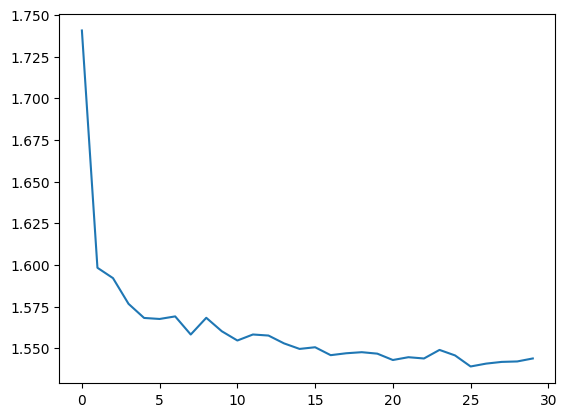

In [6]:
%%time
device='cpu'
# model = MyNn(28 * 28, 10, hidden_sz=1024).to(device)
model = MyCnn(out_sz=10, ch=32).to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
lossfn = nn.CrossEntropyLoss()
epochs = 30

loss_plot = []
for epoch in tqdm(range(epochs)):
    for i, (images, target) in enumerate(train_loader):
        optimizer.zero_grad()
        images = images.float().to(device)
        targets = target.float().to(device)

        outs = model(images)
        loss = lossfn(outs, targets.view(-1, 10))
        loss.backward()
        optimizer.step()

    losses = []
    for i, (images, target) in enumerate(val_loader):
        with torch.no_grad():
            images = images.float().to(device)
            targets = target.float().to(device)
            outs = model(images)
            loss = lossfn(outs, targets.view(-1, 10))
            losses.append(loss)
    loss_plot.append(torch.Tensor(losses).mean().item())

plt.plot(loss_plot)

In [7]:
total = len(mnist_eval)
correct = 0
with torch.no_grad():
    for image, target in mnist_eval:
        pred = model(image.float().to(device))
        if torch.allclose(pred.round().long().cpu(), target.cpu()):
            correct += 1
        
    print("{:.2f}% correct".format(100*correct/total))

91.70% correct
